In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import OrcFxAPI
import h5py
import pandas as pd


In [2]:
exp_path = r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\004\34224_03CB_02_004_002_01_Decay1.h5m"



lookback_window = 5.0      # seconden vóór decay-start waarin we de amplitude zoeken
quiet_window_end = 12.0     # rustige periode eindigt 12 s vóór decay-start
quiet_window_length = 50.0


In [3]:
with h5py.File(exp_path, "r") as f:
    t_exp = np.array(f["FittedSignals/time"])
    z_exp = np.array(f["FittedSignals/PITCH decay fit"])
    z_unf = np.array(f["UnfilteredSignals/PITCH (unfiltered)"])
    with h5py.File(exp_path, "r") as f:
        t_exp = np.array(f["FittedSignals/time"])
        z_exp = np.array(f["FittedSignals/PITCH decay fit"])
        z_unf = np.array(f["UnfilteredSignals/PITCH (unfiltered)"])
        t_unf= np.array(f["UnfilteredSignals/time"])
        
        # Print the structure of the HDF5 file
        def print_structure(name, obj):
            
            print(name)
        f.visititems(print_structure)


CroppedSignals
CroppedSignals/PITCH (LPF: 5.0 rad*s^-1)
CroppedSignals/PITCH (Mean: -0.096 [deg])
CroppedSignals/time
FittedSignals
FittedSignals/PITCH decay fit
FittedSignals/time
PQsample_based
PQsample_based/PITCH (P: 0.0 [-], Q: 0.034 [deg^-1])
PQsample_based/PITCH amplitude
Peaks
Peaks/PITCH peaks
Peaks/time
Td
Td/Number of oscillations
Td/PITCH Td (LPF: 5.0 rad*s^-1)
Td_fit
Td_fit/Number of oscillations
Td_fit/PITCH Td fit
Troughs
Troughs/PITCH troughs
Troughs/time
UnfilteredSignals
UnfilteredSignals/PITCH (unfiltered)
UnfilteredSignals/time


In [4]:


# DataFrames in één keer maken
df_exp = pd.DataFrame({
    "time [s]": t_exp,
    "time_norm [s]": t_exp - t_exp[0],
    "z_exp [m]": z_exp
})

df_unfiltered = pd.DataFrame({
    "time [s]": t_unf,
    "z_unfiltered [m]": z_unf
})

In [5]:
t_decay_start = t_exp[0]

# -----------------------------
# 2. rustige periode in ongefilterd signaal kiezen
#    van (start - quiet_window_end - quiet_window_length) tot (start - quiet_window_end)
# -----------------------------
quiet_start = t_decay_start - quiet_window_end - quiet_window_length
quiet_end = t_decay_start - quiet_window_end

mask_quiet = (t_unfiltered >= quiet_start) & (t_unfiltered <= quiet_end)

if not np.any(mask_quiet):
    raise ValueError("Geen data gevonden in de gekozen rustige periode. Kies andere vensters.")

z_eq = np.mean(z_unfiltered[mask_quiet])

# -----------------------------
# 3. zoekvenster voor initiële amplitude
#    10 s vóór decay-start
# -----------------------------
search_start = t_decay_start - lookback_window
search_end = t_decay_start

mask_search = (t_unfiltered >= search_start) & (t_unfiltered <= search_end)

if not np.any(mask_search):
    raise ValueError("Geen data gevonden in het zoekvenster vóór de decay-start.")

t_search = t_unfiltered[mask_search]
z_search = z_unfiltered[mask_search]

# afwijking t.o.v. evenwicht
deviation = z_search - z_eq

# index van grootste absolute uitslag
idx_local = np.argmax(np.abs(deviation))

t_init = t_search[idx_local]
z_init = z_search[idx_local]
A0 = np.abs(z_init - z_eq)

print(f"Decay start time           = {t_decay_start:.3f} s")
print(f"Quiet window               = [{quiet_start:.3f}, {quiet_end:.3f}] s")
print(f"Equilibrium level z_eq     = {z_eq:.6f} m")
print(f"Search window              = [{search_start:.3f}, {search_end:.3f}] s")
print(f"Initial extreme at t       = {t_init:.3f} s")
print(f"Initial extreme z          = {z_init:.6f} m")
print(f"Initial amplitude A0       = {A0:.6f} m")
print(f"Signed amplitude           = {z_init - z_eq:.6f} m")

NameError: name 't_unfiltered' is not defined

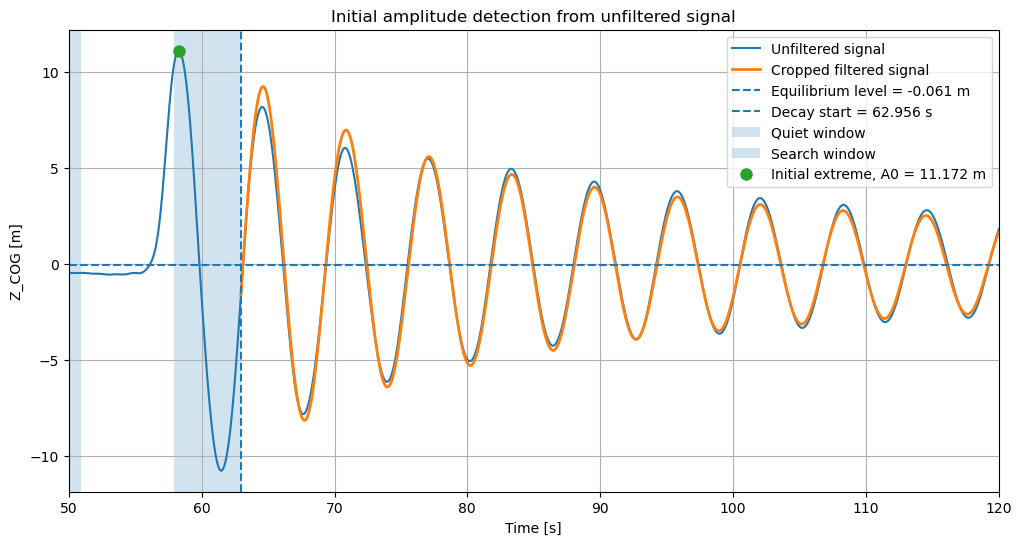

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(t_unfiltered, z_unfiltered, label="Unfiltered signal")
plt.plot(t_exp, z_exp, label="Cropped filtered signal", linewidth=2)

# evenwichtsniveau
plt.axhline(z_eq, linestyle="--", label=f"Equilibrium level = {z_eq:.3f} m")

# decay-start
plt.axvline(t_decay_start, linestyle="--", label=f"Decay start = {t_decay_start:.3f} s")

# rustige periode
plt.axvspan(quiet_start, quiet_end, alpha=0.2, label="Quiet window")

# zoekvenster
plt.axvspan(search_start, search_end, alpha=0.2, label="Search window")

# gevonden initiële amplitude
plt.plot(t_init, z_init, "o", markersize=8, label=f"Initial extreme, A0 = {A0:.3f} m")
plt.xlim(50,120)
plt.xlabel("Time [s]")
plt.ylabel("Z_COG [m]")
plt.title("Initial amplitude detection from unfiltered signal")
plt.grid(True)
plt.legend()
plt.show()

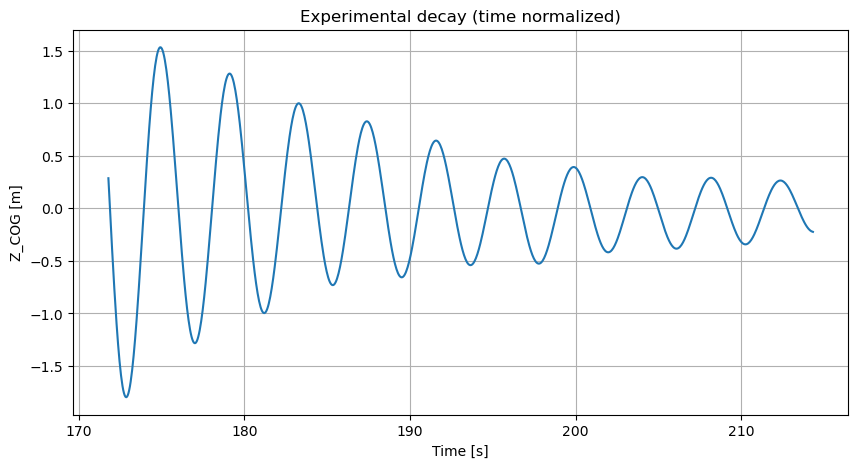

In [ ]:
# plt.figure(figsize=(10, 5))
# plt.plot(df_exp["time [s]"], df_exp["z_exp [m]"])

# plt.xlabel("Time [s]")
# plt.ylabel("Z_COG [m]")
# plt.title("Experimental decay (time normalized)")
# plt.grid(True)
# plt.show()